## import library

In [4]:
# ============================================
# 0. IMPORT LIBRARY
# ============================================
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from scipy.sparse import hstack

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. KONFIGURASI

In [5]:
# ============================================
# 1. KONFIGURASI
# ============================================
DATA_PATH = '../data/processed/data_kriminal_processed.csv'
MO_COL = 'MO_final_text'
BB_COL = 'BB_final_text'
TARGET = 'PERKARA'

# Folder penyimpanan hasil
MODEL_DIR = '../data/models/comparison_2feat_tuned'
RESULT_DIR = '../data/results/comparison_2feat_tuned'
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

# 4 skenario pembagian data (test_size)
SPLITS = [0.4, 0.3, 0.2, 0.1]  # 60:40, 70:30, 80:20, 90:10

# 2. LOAD DATA

In [6]:
# ============================================
# 2. LOAD DATA
# ============================================
print("="*60)
print("LOAD DATA")
print("="*60)
df = pd.read_csv(DATA_PATH)
X_mo = df[MO_COL].fillna('').astype(str)
X_bb = df[BB_COL].fillna('').astype(str)
X_combined = X_mo + ' ' + X_bb   # Hanya untuk tuning
y = df[TARGET]

print(f"Total data: {len(df)}")
print(f"Distribusi kelas:\n{y.value_counts()}")
print("="*60)

LOAD DATA
Total data: 592
Distribusi kelas:
PERKARA
Pencurian       224
Penganiayaan    110
Penipuan        109
Perusakan        89
Narkoba          60
Name: count, dtype: int64


# 3. BASELINE: MELATIH 4 SPLIT DENGAN PARAMETER DEFAULT

In [7]:
# ============================================
# 3. BASELINE: 4 SPLIT DENGAN PARAMETER DEFAULT
# ============================================
print("\n" + "="*60)
print("BASELINE: MELATIH 4 SPLIT DENGAN PARAMETER DEFAULT")
print("="*60)

baseline_results = []
models = {}        # simpan model per split
vectorizers = {}   # simpan vectorizer per split
predictions = {}   # simpan y_pred per split

for test_size in SPLITS:
    train_pct = int((1 - test_size) * 100)
    test_pct = int(test_size * 100)
    split_name = f"{train_pct}_{test_pct}"

    print(f"\n{'='*60}")
    print(f"--- Split {split_name} (Baseline) ---")
    print(f"{'='*60}")
    
    # --- 3.1 Stratified Split ---
    X_mo_tr, X_mo_te, X_bb_tr, X_bb_te, y_tr, y_te = train_test_split(
        X_mo, X_bb, y, test_size=test_size, random_state=42, stratify=y
    )

    # --- 3.2 TF-IDF DEFAULT ---
    print("  → TF-IDF Vectorizer (default)...")
    vec_mo = TfidfVectorizer()
    vec_bb = TfidfVectorizer()

    X_mo_tr_tf = vec_mo.fit_transform(X_mo_tr)
    X_bb_tr_tf = vec_bb.fit_transform(X_bb_tr)
    X_mo_te_tf = vec_mo.transform(X_mo_te)
    X_bb_te_tf = vec_bb.transform(X_bb_te)

    X_train = hstack([X_mo_tr_tf, X_bb_tr_tf])
    X_test = hstack([X_mo_te_tf, X_bb_te_tf])
    
    print(f"     X_train shape: {X_train.shape}")
    print(f"     X_test shape:  {X_test.shape}")

    # --- 3.3 Naive Bayes DEFAULT ---
    print("  → Training MultinomialNB (alpha=1.0)...")
    model = MultinomialNB(alpha=1.0)
    model.fit(X_train, y_tr)
    y_pred = model.predict(X_test)

    # --- 3.4 Evaluasi ---
    acc = accuracy_score(y_te, y_pred)
    report = classification_report(y_te, y_pred, output_dict=True)
    cm = confusion_matrix(y_te, y_pred)

    print(f"  ✅ Akurasi: {acc:.4f}")
    print(f"  ✅ Macro F1: {report['macro avg']['f1-score']:.4f}")
    print(f"  ✅ Weighted F1: {report['weighted avg']['f1-score']:.4f}")

    baseline_results.append({
        'Split': split_name,
        'Train Size': len(X_mo_tr),
        'Test Size': len(X_mo_te),
        'Accuracy': acc,
        'Macro F1': report['macro avg']['f1-score'],
        'Weighted F1': report['weighted avg']['f1-score']
    })

    # Simpan model, vectorizer, dan prediksi
    models[split_name] = model
    vectorizers[split_name] = {'mo': vec_mo, 'bb': vec_bb}
    predictions[split_name] = {'y_test': y_te, 'y_pred': y_pred, 'cm': cm}

    # Simpan model & vectorizer ke file (SEMUA MODEL)
    joblib.dump(model, os.path.join(MODEL_DIR, f'model_{split_name}.pkl'))
    joblib.dump(vec_mo, os.path.join(MODEL_DIR, f'vectorizer_mo_{split_name}.pkl'))
    joblib.dump(vec_bb, os.path.join(MODEL_DIR, f'vectorizer_bb_{split_name}.pkl'))

    # Simpan classification report
    with open(os.path.join(RESULT_DIR, f'report_{split_name}.txt'), 'w') as f:
        f.write(f"Classification Report - Split {split_name} (Baseline)\n")
        f.write("="*50 + "\n")
        f.write(classification_report(y_te, y_pred, digits=4))


BASELINE: MELATIH 4 SPLIT DENGAN PARAMETER DEFAULT

--- Split 60_40 (Baseline) ---
  → TF-IDF Vectorizer (default)...
     X_train shape: (355, 922)
     X_test shape:  (237, 922)
  → Training MultinomialNB (alpha=1.0)...
  ✅ Akurasi: 0.9409
  ✅ Macro F1: 0.9382
  ✅ Weighted F1: 0.9402

--- Split 70_30 (Baseline) ---
  → TF-IDF Vectorizer (default)...
     X_train shape: (414, 992)
     X_test shape:  (178, 992)
  → Training MultinomialNB (alpha=1.0)...
  ✅ Akurasi: 0.9663
  ✅ Macro F1: 0.9620
  ✅ Weighted F1: 0.9661

--- Split 80_20 (Baseline) ---
  → TF-IDF Vectorizer (default)...
     X_train shape: (473, 1074)
     X_test shape:  (119, 1074)
  → Training MultinomialNB (alpha=1.0)...
  ✅ Akurasi: 0.9664
  ✅ Macro F1: 0.9640
  ✅ Weighted F1: 0.9661

--- Split 90_10 (Baseline) ---
  → TF-IDF Vectorizer (default)...
     X_train shape: (532, 1113)
     X_test shape:  (60, 1113)
  → Training MultinomialNB (alpha=1.0)...
  ✅ Akurasi: 0.9667
  ✅ Macro F1: 0.9571
  ✅ Weighted F1: 0.9660


# 4. RINGKASAN PERBANDINGAN 4 SPLIT


📊 RINGKASAN PERBANDINGAN 4 SPLIT (BASELINE)
Split  Train Size  Test Size  Accuracy  Macro F1  Weighted F1
60_40         355        237  0.940928  0.938179     0.940244
70_30         414        178  0.966292  0.961980     0.966085
80_20         473        119  0.966387  0.963997     0.966116
90_10         532         60  0.966667  0.957103     0.965959


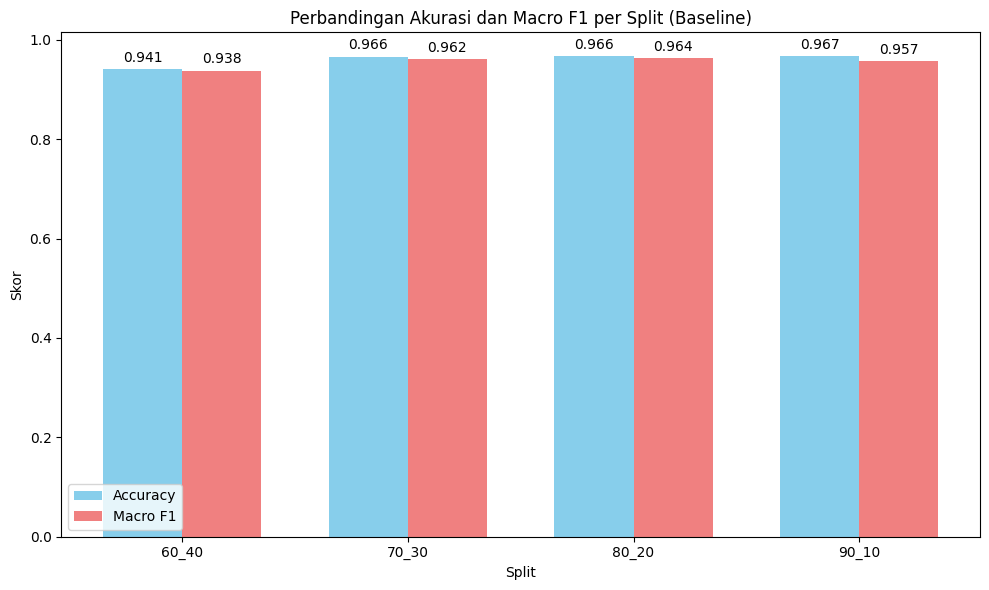


✅ Baseline selesai. Semua model & hasil tersimpan.


In [8]:
# ============================================================
# 4. RINGKASAN PERBANDINGAN 4 SPLIT
# ============================================================
print("\n" + "="*60)
print("📊 RINGKASAN PERBANDINGAN 4 SPLIT (BASELINE)")
print("="*60)

df_baseline = pd.DataFrame(baseline_results)
print(df_baseline.to_string(index=False))

# Simpan ke CSV
df_baseline.to_csv(os.path.join(RESULT_DIR, 'comparison_baseline.csv'), index=False)

# --- Visualisasi: Bar Chart Akurasi ---
fig, ax = plt.subplots(figsize=(10,6))
x = np.arange(len(df_baseline))
width = 0.35

bars1 = ax.bar(x - width/2, df_baseline['Accuracy'], width, label='Accuracy', color='skyblue')
bars2 = ax.bar(x + width/2, df_baseline['Macro F1'], width, label='Macro F1', color='lightcoral')

ax.set_xlabel('Split')
ax.set_ylabel('Skor')
ax.set_title('Perbandingan Akurasi dan Macro F1 per Split (Baseline)')
ax.set_xticks(x)
ax.set_xticklabels(df_baseline['Split'])
ax.legend()

for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'bar_accuracy_f1_baseline.png'), dpi=150)
plt.show()
plt.close()

print("\n✅ Baseline selesai. Semua model & hasil tersimpan.")


# 5. PILIH MODEL TERBAIK & VISUALISASI CONFUSION MATRIX


📊 CONFUSION MATRIX & CLASSIFICATION REPORT - SEMUA SPLIT


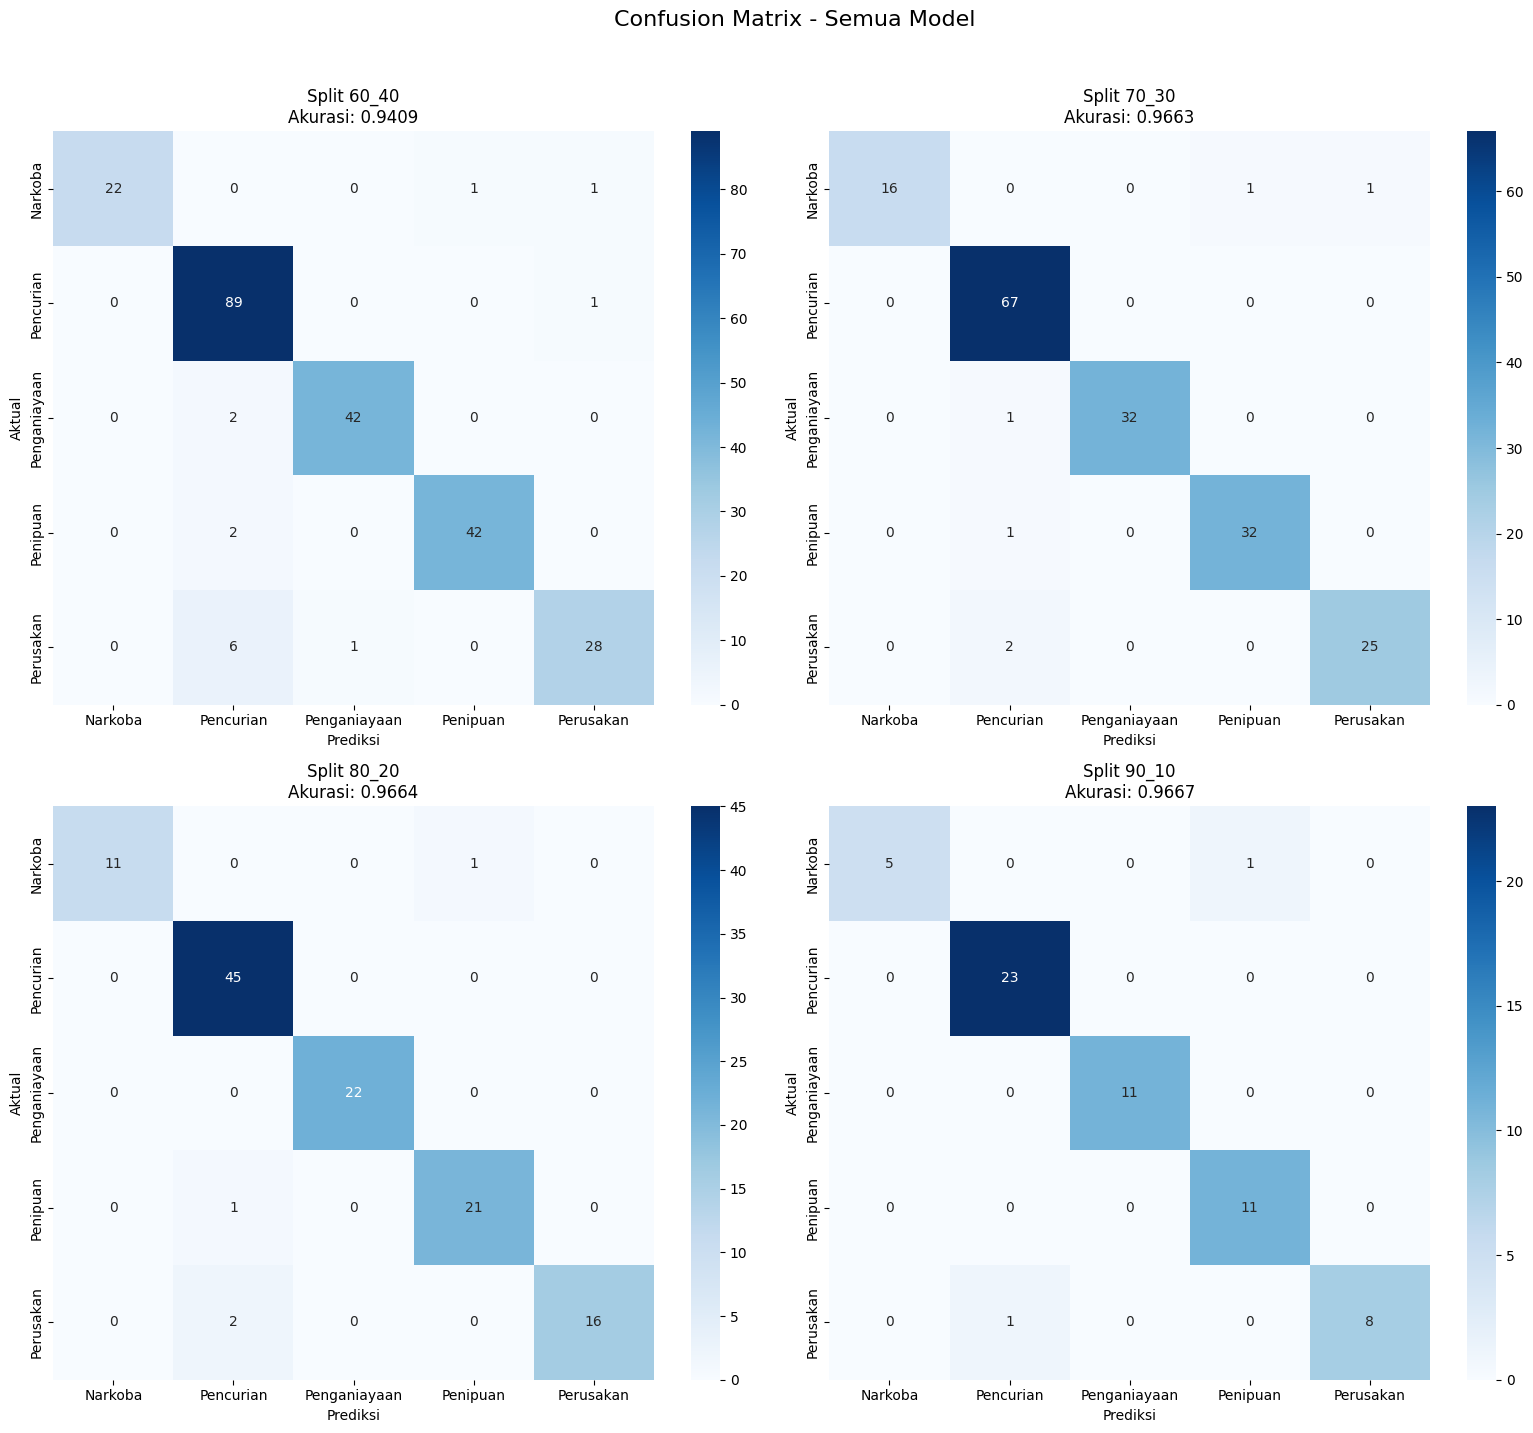

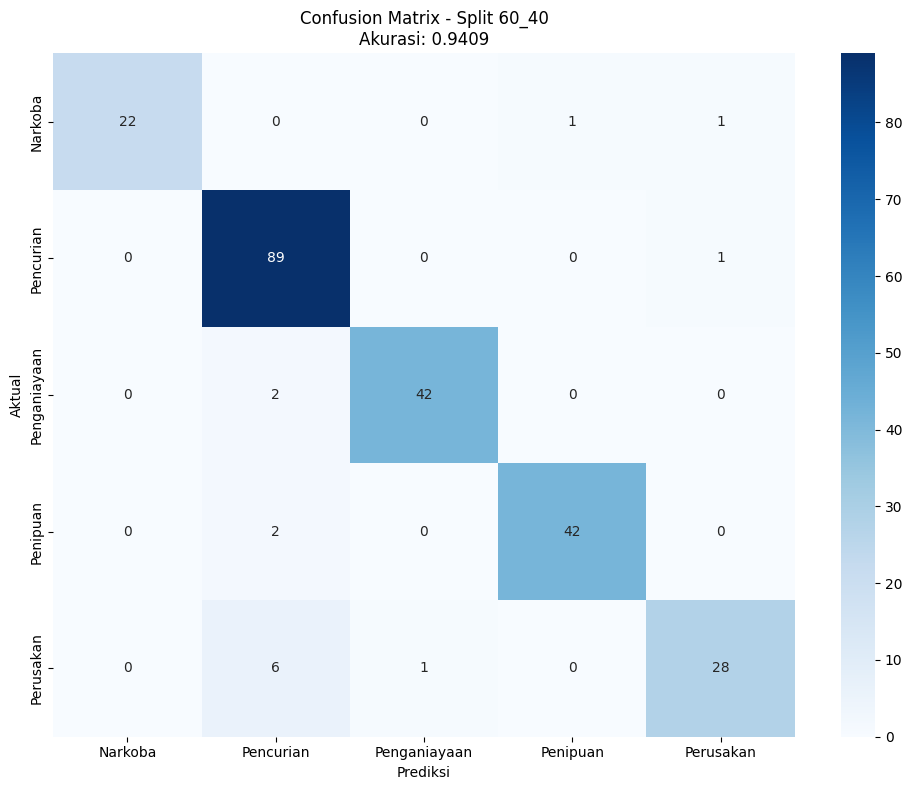

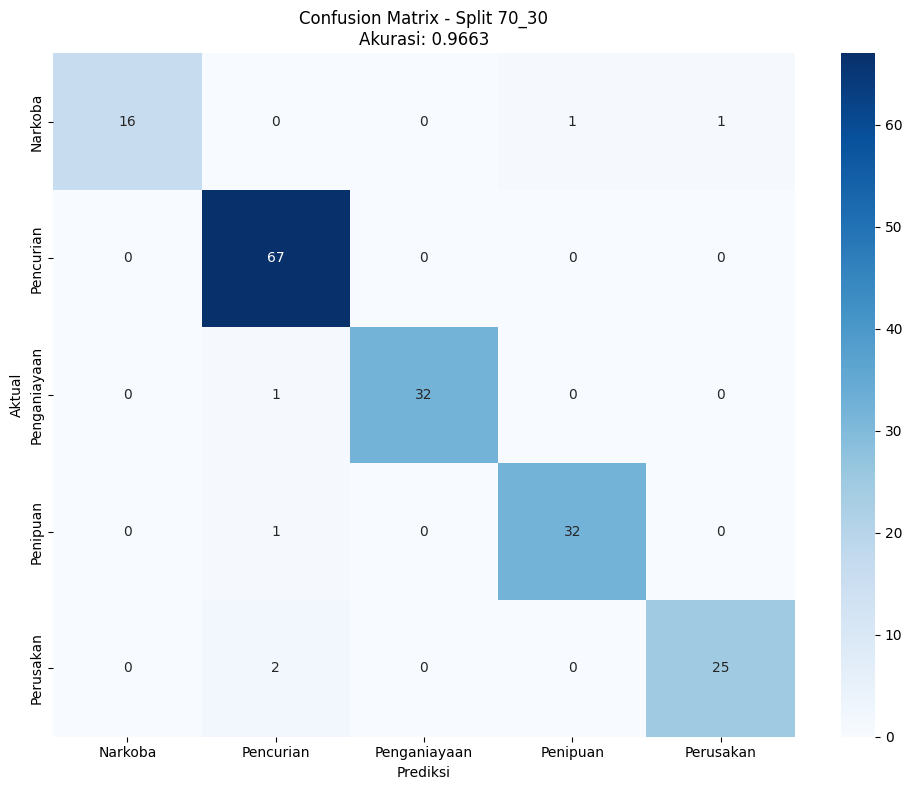

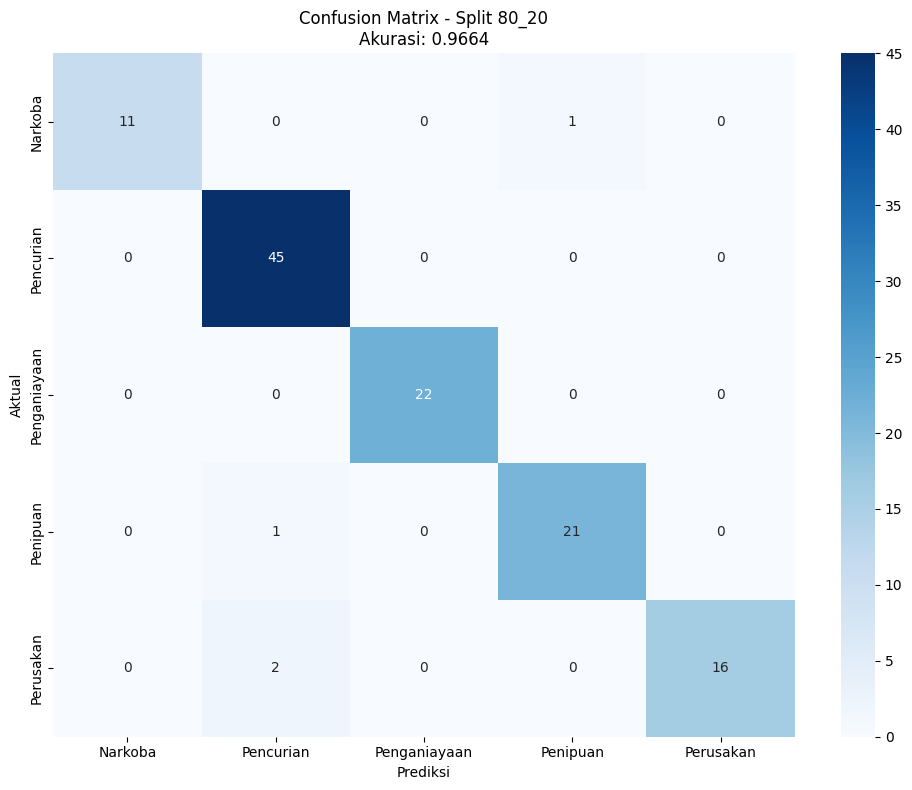

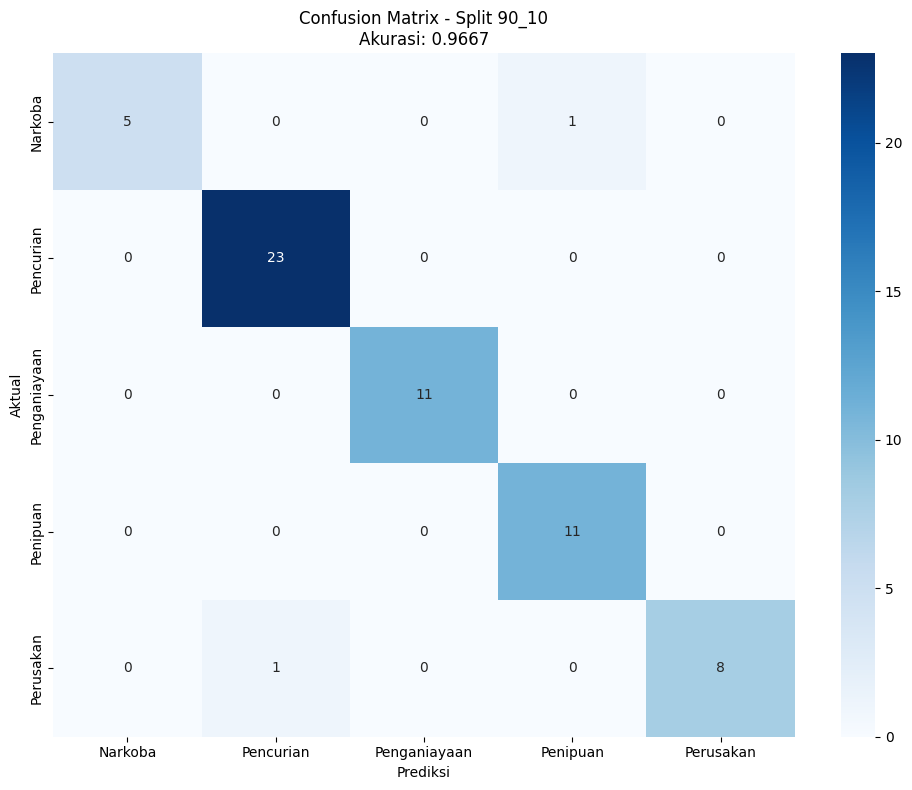


📋 CLASSIFICATION REPORT - SEMUA SPLIT

Classification Report - Split 60_40
Akurasi: 0.9409
              precision    recall  f1-score   support

     Narkoba     1.0000    0.9167    0.9565        24
   Pencurian     0.8990    0.9889    0.9418        90
Penganiayaan     0.9767    0.9545    0.9655        44
    Penipuan     0.9767    0.9545    0.9655        44
   Perusakan     0.9333    0.8000    0.8615        35

    accuracy                         0.9409       237
   macro avg     0.9572    0.9229    0.9382       237
weighted avg     0.9432    0.9409    0.9402       237


Classification Report - Split 70_30
Akurasi: 0.9663
              precision    recall  f1-score   support

     Narkoba     1.0000    0.8889    0.9412        18
   Pencurian     0.9437    1.0000    0.9710        67
Penganiayaan     1.0000    0.9697    0.9846        33
    Penipuan     0.9697    0.9697    0.9697        33
   Perusakan     0.9615    0.9259    0.9434        27

    accuracy                         0.9

In [ ]:
# ============================================================
# 5. VISUALISASI CONFUSION MATRIX & CLASSIFICATION REPORT UNTUK SEMUA MODEL
# ============================================================
print("\n" + "="*60)
print("📊 CONFUSION MATRIX & CLASSIFICATION REPORT - SEMUA SPLIT")
print("="*60)

# --- 5.1 Confusion Matrix: Subplot 2x2 untuk semua split ---
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()

for idx, (split_name, pred_data) in enumerate(predictions.items()):
    cm = pred_data['cm']
    y_te_split = pred_data['y_test']
    y_pred_split = pred_data['y_pred']
    acc_split = accuracy_score(y_te_split, y_pred_split)
    model_classes = models[split_name].classes_
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=model_classes, yticklabels=model_classes)
    axes[idx].set_xlabel('Prediksi')
    axes[idx].set_ylabel('Aktual')
    axes[idx].set_title(f'Split {split_name}\nAkurasi: {acc_split:.4f}')

plt.suptitle('Confusion Matrix - Semua Model', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'cm_all_models.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# --- 5.2 Confusion Matrix per split (individual) ---
for split_name, pred_data in predictions.items():
    cm = pred_data['cm']
    y_te_split = pred_data['y_test']
    y_pred_split = pred_data['y_pred']
    acc_split = accuracy_score(y_te_split, y_pred_split)
    model_classes = models[split_name].classes_
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=model_classes, yticklabels=model_classes)
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.title(f'Confusion Matrix - Split {split_name}\nAkurasi: {acc_split:.4f}')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULT_DIR, f'cm_model_{split_name}.png'), dpi=150)
    plt.show()
    plt.close()

# --- 5.3 Classification Report untuk SEMUA SPLIT (tampilkan & simpan) ---
print("\n" + "="*60)
print("📋 CLASSIFICATION REPORT - SEMUA SPLIT")
print("="*60)

all_reports_text = []

for split_name, pred_data in predictions.items():
    y_te_split = pred_data['y_test']
    y_pred_split = pred_data['y_pred']
    acc_split = accuracy_score(y_te_split, y_pred_split)
    
    # Buat report string
    report_header = f"\n{'='*60}\nClassification Report - Split {split_name}\nAkurasi: {acc_split:.4f}\n{'='*60}"
    report_body = classification_report(y_te_split, y_pred_split, digits=4)
    full_report = report_header + "\n" + report_body
    
    # Tampilkan di console
    print(full_report)
    
    # Kumpulkan untuk file gabungan
    all_reports_text.append(full_report)

# Simpan semua report ke 1 file gabungan
with open(os.path.join(RESULT_DIR, 'report_all_splits.txt'), 'w') as f:
    f.write("CLASSIFICATION REPORT - SEMUA SPLIT\n")
    f.write("="*60 + "\n")
    f.write("\n".join(all_reports_text))

print(f"\n✅ Classification report semua split tersimpan di: report_all_splits.txt")

# 5b. INFO MODEL TERBAIK (hanya referensi, tidak mengganti yang lain)
# ============================================================
print("\n" + "="*60)
print("🏆 INFO MODEL TERBAIK (REFERENSI)")
print("="*60)

best_idx = df_baseline['Accuracy'].idxmax()
best_split = df_baseline.loc[best_idx, 'Split']
best_acc = df_baseline.loc[best_idx, 'Accuracy']
best_macro = df_baseline.loc[best_idx, 'Macro F1']

print(f"\n🏆 Model dengan Akurasi Tertinggi: Split {best_split}")
print(f"   Akurasi: {best_acc:.4f}")
print(f"   Macro F1: {best_macro:.4f}")
print(f"\n⚠️  Catatan: Model yang DIPAKAI untuk deployment bisa berbeda dari yang terbaik.")
print(f"   Sesuaikan SPLIT di bagian 'COBA MODEL' sesuai kebutuhan Anda.")

# Simpan info model terbaik
with open(os.path.join(RESULT_DIR, 'best_model_info.txt'), 'w') as f:
    f.write(f"MODEL TERBAIK (REFERENSI)\n")
    f.write(f"Split: {best_split}\n")
    f.write(f"Akurasi: {best_acc:.4f}\n")
    f.write(f"Macro F1: {best_macro:.4f}\n")
    f.write(f"\nCatatan: Model deployment bisa berbeda.\n")


# 6. SIMPAN MODEL TERBAIK (COPY KE FILE KHUSUS)

In [10]:
# ============================================================
# 6. SIMPAN SEMUA MODEL DENGAN NAMA KHUSUS
# ============================================================
print("\n" + "="*60)
print("💾 MENYIMPAN SEMUA MODEL")
print("="*60)

for split_name in predictions.keys():
    joblib.dump(models[split_name], os.path.join(MODEL_DIR, f'model_{split_name}_final.pkl'))
    joblib.dump(vectorizers[split_name]['mo'], os.path.join(MODEL_DIR, f'vectorizer_mo_{split_name}_final.pkl'))
    joblib.dump(vectorizers[split_name]['bb'], os.path.join(MODEL_DIR, f'vectorizer_bb_{split_name}_final.pkl'))
    print(f"✅ Model {split_name} disimpan sebagai 'model_{split_name}_final.pkl'")

# Simpan juga model terbaik dengan nama khusus
joblib.dump(models[best_split], os.path.join(MODEL_DIR, 'model_best.pkl'))
joblib.dump(vectorizers[best_split]['mo'], os.path.join(MODEL_DIR, 'vectorizer_mo_best.pkl'))
joblib.dump(vectorizers[best_split]['bb'], os.path.join(MODEL_DIR, 'vectorizer_bb_best.pkl'))
print(f"✅ Model terbaik ({best_split}) juga disimpan sebagai 'model_best.pkl'")


💾 MENYIMPAN SEMUA MODEL
✅ Model 60_40 disimpan sebagai 'model_60_40_final.pkl'
✅ Model 70_30 disimpan sebagai 'model_70_30_final.pkl'
✅ Model 80_20 disimpan sebagai 'model_80_20_final.pkl'
✅ Model 90_10 disimpan sebagai 'model_90_10_final.pkl'
✅ Model terbaik (90_10) juga disimpan sebagai 'model_best.pkl'


# 7. RINGKASAN AKHIR

In [11]:
# ============================================================
# 7. RINGKASAN AKHIR
# ============================================================
print("\n" + "="*60)
print("📊 RINGKASAN AKHIR")
print("="*60)
print(f"Total sampel: {len(df)}")
print(f"Skenario split: 60:40, 70:30, 80:20, 90:10")
print(f"Model dengan akurasi tertinggi: Split {best_split} (Akurasi: {best_acc:.4f})")
print(f"📁 Semua model tersimpan di: {MODEL_DIR}")
print(f"📁 Hasil evaluasi tersimpan di: {RESULT_DIR}")
print("✅ Selesai!")


📊 RINGKASAN AKHIR
Total sampel: 592
Skenario split: 60:40, 70:30, 80:20, 90:10
Model dengan akurasi tertinggi: Split 90_10 (Akurasi: 0.9667)
📁 Semua model tersimpan di: ../data/models/comparison_2feat_tuned
📁 Hasil evaluasi tersimpan di: ../data/results/comparison_2feat_tuned
✅ Selesai!


### COBA MODEL

In [ ]:
# ============================================
# 1. LOAD MODEL DAN VECTORIZER (PILIH SPLIT)
# ============================================
# PILIH SPLIT YANG MAU DIPAKAI:
# - '60_40', '70_30', '80_20', '90_10'  → model spesifik
# - 'best'                               → auto-load model dengan akurasi tertinggi
#
# 💡 TIPS: Ganti SPLIT sesuai kebutuhan deployment Anda.
#    Meskipun 90:10 akurasinya tinggi, gunakan 80:20 jika itu yang lebih cocok.
SPLIT = '80_20'  # <-- GANTI SESUAI KEBUTUHAN ANDA

MODEL_DIR = '../data/models/comparison_2feat_tuned'
RESULT_DIR = '../data/results/comparison_2feat_tuned'

# Jika memilih 'best', otomatis load model dengan akurasi tertinggi
if SPLIT == 'best':
    df_compare = pd.read_csv(os.path.join(RESULT_DIR, 'comparison_baseline.csv'))
    best_row = df_compare.loc[df_compare['Accuracy'].idxmax()]
    SPLIT = best_row['Split']
    print(f"Auto-load model terbaik: Split {SPLIT}")

model = joblib.load(os.path.join(MODEL_DIR, f'model_{SPLIT}.pkl'))
vectorizer_mo = joblib.load(os.path.join(MODEL_DIR, f'vectorizer_mo_{SPLIT}.pkl'))
vectorizer_bb = joblib.load(os.path.join(MODEL_DIR, f'vectorizer_bb_{SPLIT}.pkl'))

print(f"✅ Model dan vectorizer (Split {SPLIT}) berhasil dimuat!")

# ============================================
# 2. FUNGSI PREPROCESSING (Jika diperlukan)
# ============================================
def preprocess_text(text):
    return text

# ============================================
# 3. FUNGSI PREDIKSI
# ============================================
def predict_crime(mo_text, bb_text):
    mo_text = str(mo_text).strip()
    bb_text = str(bb_text).strip()
    
    if mo_text == '':
        mo_text = ' '
    if bb_text == '':
        bb_text = ' '
    
    mo_tfidf = vectorizer_mo.transform([mo_text])
    bb_tfidf = vectorizer_bb.transform([bb_text])
    X_combined = hstack([mo_tfidf, bb_tfidf])
    
    prediksi = model.predict(X_combined)[0]
    proba = model.predict_proba(X_combined)[0]
    
    return prediksi, proba

# ============================================
# 4. CONTOH PENGGUNAAN
# ============================================
contoh_mo = "pelaku mengambil handphone korban saat tidur"
contoh_bb = "handphone"

hasil, prob = predict_crime(contoh_mo, contoh_bb)

print(f"📝 Teks MO : {contoh_mo}")
print(f"📝 Teks BB : {contoh_bb}")
print(f"🏷️ Hasil Prediksi : {hasil}")
print(f"📊 Probabilitas per kelas:")
for i, kelas in enumerate(model.classes_):
    print(f"   {kelas}: {prob[i]:.4f}")

✅ Model dan vectorizer (Split 80_20) berhasil dimuat!
📝 Teks MO : pelaku mengambil handphone korban saat tidur
📝 Teks BB : handphone
🏷️ Hasil Prediksi : Pencurian
📊 Probabilitas per kelas:
   Narkoba: 0.0098
   Pencurian: 0.9444
   Penganiayaan: 0.0133
   Penipuan: 0.0111
   Perusakan: 0.0214
